In [ ]:
# Import the libraries we need
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:

# Connecting Dataset

DATASET_DIR = "/content/drive/MyDrive/Signals Speech & Img Processing/Signal Data Sets"

# The two class folders inside the dataset
NORMAL_DIR = os.path.join(DATASET_DIR, "Normal")
ABNORMAL_DIR = os.path.join(DATASET_DIR, "Abnormal")

# Folder where all generated images will be saved
OUTPUT_DIR = os.path.join(DATASET_DIR, "Processed_Images")

# Create output folders
os.makedirs(os.path.join(OUTPUT_DIR, "Normal"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "Abnormal"), exist_ok=True)

print("Dataset path:", DATASET_DIR)
print("Normal folder:", NORMAL_DIR)
print("Abnormal folder:", ABNORMAL_DIR)
print("Output folder:", OUTPUT_DIR)

Dataset path: /content/drive/MyDrive/Signals Speech & Img Processing/Signal Data Sets
Normal folder: /content/drive/MyDrive/Signals Speech & Img Processing/Signal Data Sets/Normal
Abnormal folder: /content/drive/MyDrive/Signals Speech & Img Processing/Signal Data Sets/Abnormal
Output folder: /content/drive/MyDrive/Signals Speech & Img Processing/Signal Data Sets/Processed_Images


In [ ]:
# Checking whether the two required folders actually exist
print("Normal exists:", os.path.exists(NORMAL_DIR))
print("Abnormal exists:", os.path.exists(ABNORMAL_DIR))

# Count WAV files in each class
normal_files = [f for f in os.listdir(NORMAL_DIR) if f.lower().endswith(".wav")]
abnormal_files = [f for f in os.listdir(ABNORMAL_DIR) if f.lower().endswith(".wav")]

print("Normal WAV files:", len(normal_files))
print("Abnormal WAV files:", len(abnormal_files))

Normal exists: True
Abnormal exists: True
Normal WAV files: 20
Abnormal WAV files: 25


In [ ]:
# Each audio segment will be containing 128 × 128 samples
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128

# Number of audio samples needed to create one image
SAMPLES_PER_IMAGE = IMAGE_HEIGHT * IMAGE_WIDTH

print("Samples required for one image:", SAMPLES_PER_IMAGE)

Samples required for one image: 16384


In [ ]:
# Taking the first WAV file from the Normal folder
sample_file = os.path.join(NORMAL_DIR, normal_files[0])

# Reading the WAV file as a 1D audio signal
# sr=None keeps the original sampling rate
# mono=True converts the audio into one channel
signal, sr = librosa.load(sample_file, sr=None, mono=True)

# Display basic information
print("File:", sample_file)
print("Sampling rate:", sr)
print("Signal shape:", signal.shape)
print("Number of samples:", len(signal))

File: /content/drive/MyDrive/Signals Speech & Img Processing/Signal Data Sets/Normal/1100010017_ToyCar_case1_normal_IND_ch1_0017.wav
Sampling rate: 48000
Signal shape: (528000,)
Number of samples: 528000


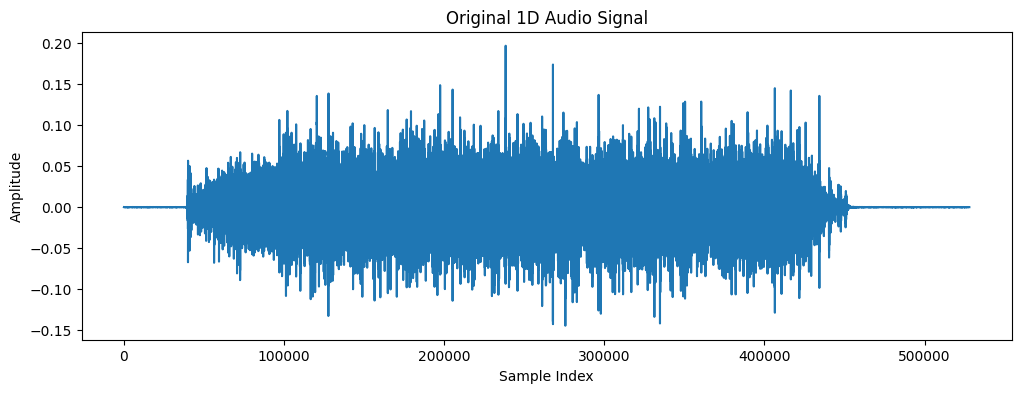

In [ ]:
# Creating a plot for the original audio signal
plt.figure(figsize=(12, 4))

# Plot amplitude against sample index
plt.plot(signal)

# Add labels
plt.title("Original 1D Audio Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")

# Display the graph
plt.show()

In [ ]:
# Calculate how many complete 128×128 images can be made
num_images = len(signal) // SAMPLES_PER_IMAGE

print("Number of complete images:", num_images)

# Keep only the samples that can be completely reshaped
usable_samples = num_images * SAMPLES_PER_IMAGE

# Remove leftover samples
trimmed_signal = signal[:usable_samples]

# Convert the 1D signal into:
# num_images × 128 × 128
image_matrices = trimmed_signal.reshape(
    num_images,
    IMAGE_HEIGHT,
    IMAGE_WIDTH
)

# Display the resulting shape
print("Image matrix shape:", image_matrices.shape)

Number of complete images: 32
Image matrix shape: (32, 128, 128)


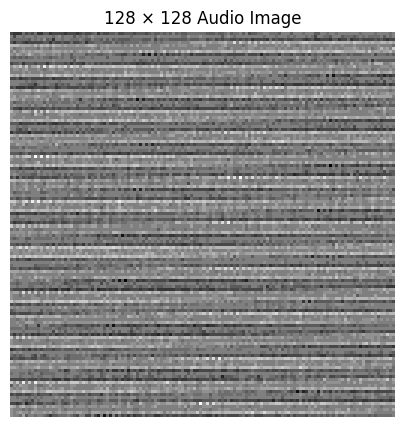

In [ ]:
# Select the first 128×128 matrix
first_image = image_matrices[0]

# Normalize the values to 0–255 so they can be saved as an image
image_data = first_image - first_image.min()
image_data = image_data / image_data.max()
image_data = (image_data * 255).astype(np.uint8)

# Create the image
img = Image.fromarray(image_data)

# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("128 × 128 Audio Image")
plt.axis("off")
plt.show()

In [ ]:
# Getting the original WAV file name without ".wav"
base_name = os.path.splitext(os.path.basename(sample_file))[0]

# Save every generated image
for i in range(num_images):

    # Get one 128×128 matrix
    current_image = image_matrices[i]

    # Normalize matrix values to 0–255
    normalized = current_image - current_image.min()

    # Avoid division by zero for a completely silent segment
    if normalized.max() > 0:
        normalized = normalized / normalized.max()

    normalized = (normalized * 255).astype(np.uint8)

    # Convert matrix to an image
    img = Image.fromarray(normalized)

    # Create a unique image filename
    output_name = f"{base_name}_segment_{i+1}.png"

    # Create the complete output path
    output_path = os.path.join(
        OUTPUT_DIR,
        "Normal",
        output_name
    )

    # Save image
    img.save(output_path)

print("Finished saving images for:", base_name)

Finished saving images for: 1100010017_ToyCar_case1_normal_IND_ch1_0017


In [ ]:
# This function processes every WAV file in one class folder
def process_class(input_folder, output_folder, class_name):

    # Get all WAV files
    wav_files = [
        f for f in os.listdir(input_folder)
        if f.lower().endswith(".wav")
    ]

    # Count total generated images
    total_images = 0

    print(f"\nProcessing {class_name} class...")
    print("WAV files found:", len(wav_files))

    # Process every WAV file
    for file_name in wav_files:

        # Create complete input file path
        file_path = os.path.join(input_folder, file_name)

        # Read the audio as a 1D signal
        signal, sr = librosa.load(
            file_path,
            sr=None,
            mono=True
        )

        # Calculate number of complete 128×128 images
        num_images = len(signal) // SAMPLES_PER_IMAGE

        # Ignore leftover samples
        usable_samples = num_images * SAMPLES_PER_IMAGE
        trimmed_signal = signal[:usable_samples]

        # Converting 1D signal into multiple 128×128 matrices
        image_matrices = trimmed_signal.reshape(
            num_images,
            IMAGE_HEIGHT,
            IMAGE_WIDTH
        )

        # Getting WAV filename without extension
        base_name = os.path.splitext(file_name)[0]

        # Save each matrix as a PNG image
        for i in range(num_images):

            # Select one matrix
            current_image = image_matrices[i]

            # Normalize matrix values
            normalized = current_image - current_image.min()

            # Handle silent segments safely
            if normalized.max() > 0:
                normalized = normalized / normalized.max()

            # Converting values to 0–255
            normalized = (normalized * 255).astype(np.uint8)

            # Converting matrix to image
            img = Image.fromarray(normalized)

            # Creating output filename
            output_name = f"{base_name}_segment_{i+1}.png"

            # Creating output path
            output_path = os.path.join(
                output_folder,
                output_name
            )

            # Save image
            img.save(output_path)

            # Increase total image count
            total_images += 1

    print(f"{class_name} processing complete.")
    print("Images generated:", total_images)

    return total_images

In [ ]:
# Process all Normal WAV files
normal_count = process_class(
    NORMAL_DIR,
    os.path.join(OUTPUT_DIR, "Normal"),
    "Normal"
)

# Process all Abnormal WAV files
abnormal_count = process_class(
    ABNORMAL_DIR,
    os.path.join(OUTPUT_DIR, "Abnormal"),
    "Abnormal"
)

# Display final totals
print("\n==============================")
print("FINAL DATASET")
print("==============================")
print("Normal images:", normal_count)
print("Abnormal images:", abnormal_count)
print("Total images:", normal_count + abnormal_count)


Processing Normal class...
WAV files found: 20
Normal processing complete.
Images generated: 640

Processing Abnormal class...
WAV files found: 25
Abnormal processing complete.
Images generated: 800

FINAL DATASET
Normal images: 640
Abnormal images: 800
Total images: 1440


In [ ]:
# Count the saved PNG files in each class
saved_normal = len([
    f for f in os.listdir(os.path.join(OUTPUT_DIR, "Normal"))
    if f.lower().endswith(".png")
])

saved_abnormal = len([
    f for f in os.listdir(os.path.join(OUTPUT_DIR, "Abnormal"))
    if f.lower().endswith(".png")
])

print("Saved Normal images:", saved_normal)
print("Saved Abnormal images:", saved_abnormal)
print("Saved Total images:", saved_normal + saved_abnormal)

Saved Normal images: 640
Saved Abnormal images: 800
Saved Total images: 1440


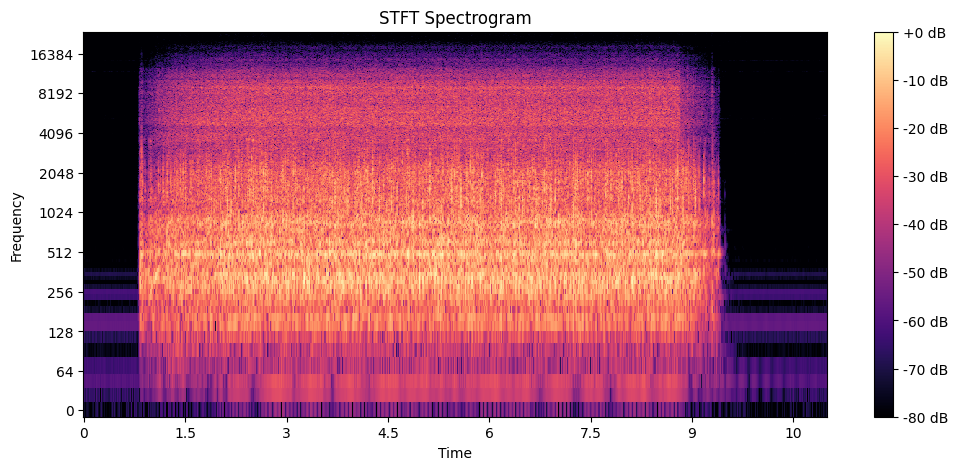

In [ ]:
# Generate an STFT spectrogram from the audio signal

# Calculate the Short-Time Fourier Transform
stft = librosa.stft(
    signal,
    n_fft=2048,
    hop_length=512
)

# Convert complex STFT values to magnitude
magnitude = np.abs(stft)

# Convert magnitude into decibels
stft_db = librosa.amplitude_to_db(
    magnitude,
    ref=np.max
)

# Display the spectrogram
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    stft_db,
    sr=sr,
    x_axis="time",
    y_axis="log"
)

plt.colorbar(format="%+2.0f dB")
plt.title("STFT Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()